In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
from maploc.demo import Demo, read_input_image

# Increasing the number of rotations increases the accuracy but requires more GPU memory.
# The highest accuracy is achieved with num_rotations=360
# but num_rotations=64~128 is often sufficient.
# To reduce the memory usage, we can reduce the tile size in the next cell.
demo = Demo(experiment_or_path="prerelease/prerelease.ckpt", num_rotations=64, device="cpu")

[2024-09-05 03:06:21 maploc INFO] Using prior address 'ETH CAB, 6, Universitätstrasse, Oberstrass, Kreis 6, Zürich, Bezirk Zürich, Zürich, 8092, Schweiz/Suisse/Svizzera/Svizra'
[2024-09-05 03:06:21 maploc INFO] Could not call PerspectiveFields, maybe install gradio_client?
[2024-09-05 03:06:21 maploc INFO] Using cam_R_gcam tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]).
[2024-09-05 03:06:21 maploc INFO] Calling the OpenStreetMap API...
100%|██████████| 9/9 [00:00<00:00, 45.94it/s]
[2024-09-05 03:06:22 maploc INFO] Calling the OpenStreetMap API...
100%|██████████| 9/9 [00:00<00:00, 99.75it/s]


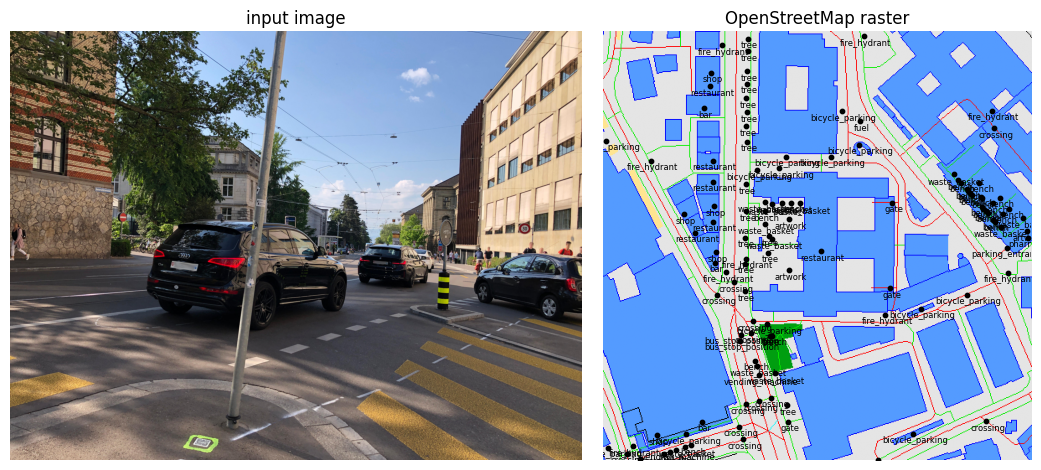

In [3]:
# no EXIF data: provide a coarse location prior as address
image_path = "assets/query_zurich_1.jpeg"
prior_address = "ETH CAB Zurich"
# Try out these other queries!
# image_path = "assets/query_vancouver_1.JPG"
# prior_address = "Vancouver Waterfront Station"

# image_path = "assets/query_vancouver_2.JPG"
# image_path = "assets/query_vancouver_3.JPG"
# prior_address = None # here we load the location prior from the exif

image, camera, cam_R_gcam, proj, bbox, prior_latlon = read_input_image(
    image_path,
    prior_address=prior_address,
    tile_size_meters=128,  # try 64, 256, etc.
)

# Show the query area in an interactive map
from maploc.osm.viz import GeoPlotter

# plot = GeoPlotter(zoom=16)
# plot.points(prior_latlon[:2], "red", name="location prior", size=10)
# plot.bbox(proj.unproject(bbox), "blue", name="map tile")
# plot.fig.show("notebook")

# Query OpenStreetMap for this area
from maploc.osm.tiling import TileManager

ppm_list = demo.config.data.pixel_per_meter
canvas = {}
for i,z_max in enumerate(demo.config.data.z_max):

    ppm = ppm_list[i]
    tiler = TileManager.from_bbox(proj, bbox + 10, ppm)
    canvas[z_max] = tiler.query(bbox)

# Show the inputs to the model: image and raster map
from maploc.osm.viz import Colormap, plot_nodes
from maploc.utils.viz_2d import plot_images

depth32m = demo.config.data.z_max[0] # corresponds to finer ppm
map_viz = Colormap.apply(canvas[depth32m].raster)
plot_images([image, map_viz], titles=["input image", "OpenStreetMap raster"])
plot_nodes(1, canvas[depth32m].raster[2], fontsize=6, size=10)

In [4]:
from maploc.utils.viz_localization import (
    likelihood_overlay,
    plot_dense_rotations,
    add_circle_inset,
)
from maploc.utils.viz_2d import features_to_RGB


# Run the inference
tile_T_cam_max, map_T_cam_max, prob, neural_map, image, semantic_map = demo.localize(
    image, camera, canvas, cam_R_gcam=cam_R_gcam
)

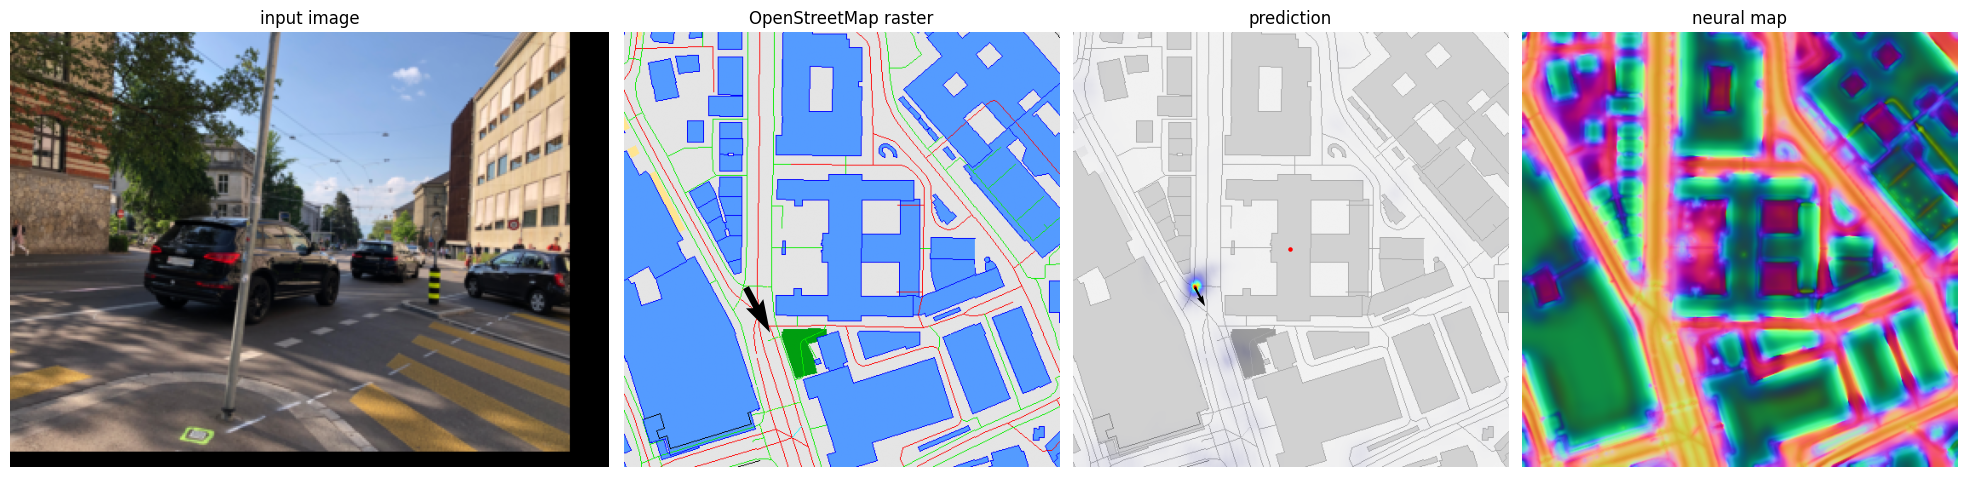

In [5]:
import numpy as np
import torch

depth32m = demo.config.data.z_max[0] # corresponds to finer ppm
# Get the memory-layout map raster from localize() output
map_viz = Colormap.apply(semantic_map[depth32m])

# Visualize the predictions
overlay = likelihood_overlay(prob.squeeze(0).numpy().max(-1), map_viz.mean(-1, keepdims=True))
(neural_map_rgb,) = features_to_RGB(neural_map.squeeze(0).numpy())

overlay, neural_map_rgb, map_viz = [
    np.swapaxes(x, 0, 1) for x in (overlay, neural_map_rgb, map_viz)
]

from maploc.utils.viz_localization import plot_pose
from maploc.utils.wrappers import Transform2D

map_T_cam_max = Transform2D.to_pixels(tile_T_cam_max, 1 / 2)

plot_images([image.permute(1,2,0), map_viz, overlay, neural_map_rgb], titles=["input image", "OpenStreetMap raster", "prediction", "neural map"],
            origins=["upper", "lower", "lower", "lower"])
ax = plt.gcf().axes[2]
ax.scatter(*canvas[32.0].to_uv(bbox.center), s=5, c="red")
plot_dense_rotations(ax, prob.squeeze(0), w=0.005, s=1 / 25)

plot_pose(
        [1],
        map_T_cam_max.t.squeeze(0),
        map_T_cam_max.angle.squeeze(0),
        c="k",
        refactored=True,
        dot=False,
        s=1/60
        )
# add_circle_inset(ax, uv) # still broken
plt.show("notebook")

# Plot as interactive figure
bbox_latlon = proj.unproject(canvas[32.0].bbox)
plot = GeoPlotter(zoom=16.5)
plot.raster(np.flipud(map_viz), bbox_latlon, opacity=0.5)
overlay = likelihood_overlay(prob.squeeze(0).numpy().max(-1))
overlay = np.swapaxes(overlay, 0, 1)
plot.raster(np.flipud(overlay), proj.unproject(bbox))
plot.points(prior_latlon[:2], "red", name="location prior", size=10)
uv = map_T_cam_max.t
uv[...,-1] = canvas[32.0].h - uv[...,-1]
plot.points(proj.unproject(canvas[32.0].to_xy(map_T_cam_max.t)), "black", name="argmax", size=10) # fixme
plot.bbox(bbox_latlon, "blue", name="map tile")
plot.fig.show()